In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
font_prop = fm.FontProperties(family="Times New Roman", size=19)


In [2]:
def color_mapping_viridis(val):
    if isinstance(val, (int, float)):
        normed_value = (val - 0.8 + 0.1) / 0.2  # Normalize the value to [0, 1] based on the range [0.8, 1]
        rgba = plt.cm.viridis(normed_value)
        return rgba
    else:
        return '#FFFFFF'

In [3]:
def plot_colored_table(data_dict, save_path='test.png'):
    # Convert data to DataFrame
    df = pd.DataFrame(data_dict)
    cell_height = 0.8
    # Format all numeric values to have three decimal places and get the color mapping
    formatted_df = df.applymap(lambda x: '{:.2f}'.format(100*x) if isinstance(x, float) else x)
    colors_viridis = df.applymap(color_mapping_viridis)

    # Adjust the cell heights to make them square
    num_rows, num_cols = df.shape
    fig_height = cell_height * (num_rows + 1)  # +1 for the header row

    # Correctly calculating the fig_width
    fig_width = cell_height * (num_cols + 2)  # +2 to accommodate for the colorbar and spacing

    # Plotting
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')

    # Display the table
    table = ax.table(cellText=formatted_df.values, colLabels=df.columns, cellLoc='center', loc='center', 
                     colWidths=[0.2] * num_cols, cellColours=colors_viridis.values, bbox=[0, 0, 1, 1])

    # Adjust cell heights to make them square
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, cell_height)
    for _, cell in table.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)
        cell._text.set_fontproperties(font_prop)

    norm = plt.Normalize(80, 90)
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),ticks=[80, 85, 90, 95, 100], orientation="vertical")
    #cb_title = cb.ax.set_title('DICE(%)', fontproperties=font_prop)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()



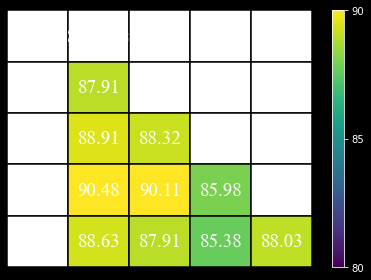

In [4]:
# Test the function with the provided data
# 0.879132543	0.837361942	0.758144643	0.710289693
# 0.88906338	0.88315857	0.801471959	0.752759662
# 0.904804107	0.901144023	0.859780205	0.760208002
# 0.886301727	0.879144033	0.853818312	0.880311335
new_data = {
    'Dom.': ['Step1', 'Step2', 'Step3', 'Step4'],
    'Siemens': [0.879132543, 0.88906338, 0.904804107, 0.886301727],
    'Philips': ['', 0.88315857, 0.901144023, 0.879144033],
    'GE': ['', '', 0.859780205, 0.853818312],
    'Canon': ['', '', '', 0.880311335]
}
plot_colored_table(new_data, 'Dom.png')


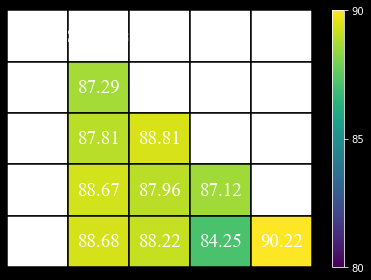

In [5]:
# 0.872932198	0.829505653	0.743496265	0.70787598
# 0.878147744	0.888139423	0.790336673	0.67482689
# 0.886651009	0.879619287	0.871248162	0.63604094
# 0.886791812	0.882248778	0.842470998	0.902170463

new_data = {
    'Ana.': ['Step1', 'Step2', 'Step3', 'Step4'],
    'Siemens': [0.872932198, 0.878147744, 0.886651009, 0.886791812],
    'Philips': ['', 0.888139423, 0.879619287, 0.882248778],
    'GE': ['', '', 0.871248162, 0.842470998],
    'Canon': ['', '', '', 0.902170463]
}
plot_colored_table(new_data, 'Ana.png')


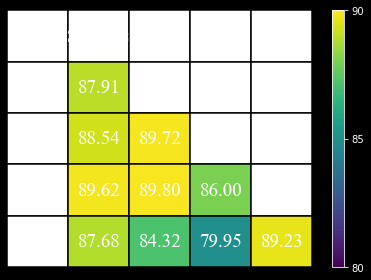

In [6]:
# 0.879132543	0.837361942	0.758144643	0.710289693
# 0.885419203	0.897242965	0.803182674	0.717628011
# 0.896159553	0.898036138	0.859974768	0.626382343
# 0.876828995	0.843197336	0.799540687	0.89227081

new_data = {
    'KD': ['Step1', 'Step2', 'Step3', 'Step4'],
    'Siemens': [0.879132543, 0.885419203, 0.896159553, 0.876828995],
    'Philips': ['', 0.897242965, 0.898036138, 0.843197336],
    'GE': ['', '', 0.859974768, 0.799540687],
    'Canon': ['', '', '', 0.89227081]
}
plot_colored_table(new_data, 'kd.png')


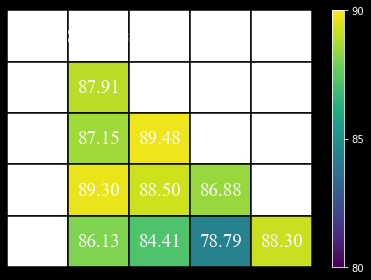

In [7]:
# 0.87913	0.83736	0.75814	0.71029
# 0.87149	0.8948	0.79662	0.67896
# 0.89304	0.88503	0.8688	0.74156
# 0.86135	0.84406	0.78786	0.88298

new_data = {
    'SEQ': ['Step1', 'Step2', 'Step3', 'Step4'],
    'Siemens': [0.87913, 0.87149, 0.89304, 0.86135],
    'Philips': ['', 0.8948, 0.88503, 0.84406],
    'GE': ['', '', 0.8688, 0.78786],
    'Canon': ['', '', '', 0.88298]
}
plot_colored_table(new_data, 'SEQ.png')
